In [ ]:
# simple neural network fitting a sine curve

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.figsize': (6, 4),
    'font.size': 12,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [ ]:
# generate training data
torch.manual_seed(42)
N = 50
x_train = torch.linspace(-2 * np.pi, 2 * np.pi, N).unsqueeze(1)
y_train = torch.sin(x_train) + 0.1 * torch.randn_like(x_train)  # add a bit of noise

x_plot = torch.linspace(-2 * np.pi, 2 * np.pi, 500).unsqueeze(1)

In [3]:
# tiny neural network
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

loss_fn = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

In [4]:

n_iters = 2000
snapshot_iters = [0, 100, 500, 2000]
snapshots = {}
losses = []


with torch.no_grad():
    snapshots[0] = model(x_plot).numpy().copy()

for t in range(1, n_iters + 1):
    pred = model(x_train)
    loss = loss_fn(pred, y_train)

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    losses.append(loss.item())

    if t in snapshot_iters:
        with torch.no_grad():
            snapshots[t] = model(x_plot).numpy().copy()

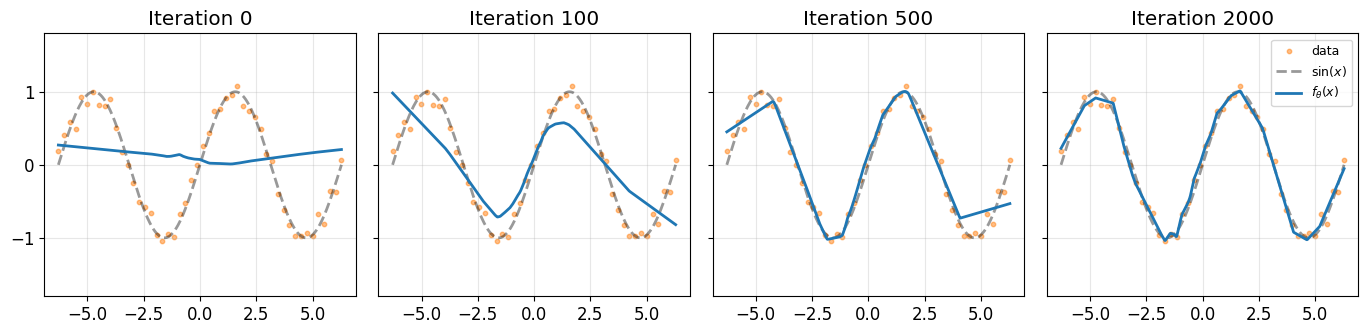

In [ ]:

fig, axes = plt.subplots(1, len(snapshot_iters), figsize=(14, 3.5), sharey=True)

for ax, it in zip(axes, snapshot_iters):
    ax.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.5, c='tab:orange', label='data')
    ax.plot(x_plot.numpy(), np.sin(x_plot.numpy()), 'k--', alpha=0.4, label=r'$\sin(x)$')
    ax.plot(x_plot.numpy(), snapshots[it], c='tab:blue', label=r'$f_\theta(x)$')
    ax.set_title(f'Iteration {it}')
    ax.set_ylim(-1.8, 1.8)

axes[-1].legend(fontsize=9, loc='upper right')
plt.tight_layout()
#plt.savefig('nn_fit_snapshots.pdf', bbox_inches='tight')
plt.show()